Reproduction of  "Grokking modular arithmetic" by Andrey Gromov 

In [3]:
!git clone https://github.com/naxilef/Grokking-Project.git
%cd /content/Grokking-Project

Cloning into 'Grokking-Project'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 59 (delta 26), reused 43 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 4.61 MiB | 9.11 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/Grokking-Project


In [4]:
import math
import json
from pathlib import Path

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from models.modular_mlp import ModularMLP
from data.modular_arith import generate_all_pair, encode_pair, modular_addition, split_dataset, make_modular_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def weight_norms(model):
    return (
        model.W1.weight.detach().norm().item(),
        model.W2.weight.detach().norm().item(),
    )

def grad_norms(model):
    g1 = model.W1.weight.grad.norm().item() if model.W1.weight.grad is not None else 0.0
    g2 = model.W2.weight.grad.norm().item() if model.W2.weight.grad is not None else 0.0
    return g1, g2

@torch.no_grad()
def evaluate(model, loader, p, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for x,y in loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        y_onehot = F.one_hot(y, num_classes=p).float()
        loss = F.mse_loss(outputs, y_onehot)

        total_loss += loss.item() * x.size(0)
        total_correct += (torch.argmax(outputs, dim=1) == y).sum().item()
        total_count += x.size(0)

    return {
        "loss": total_loss / total_count,
        "acc": total_correct / total_count,
    }

def train(
        p=97,
    hidden_dim=512,
    alpha=0.49,
    seed=0,
    activation="quadratic",
    lr=1e-2,
    epochs=200_000,
    eval_every=100,
    optimizer_name="sgd",
    weight_decay=0.0,
):
    torch.manual_seed(seed)

    arith_tensor = make_modular_dataset(p, modular_addition)

    train_dataset, test_dataset = split_dataset(arith_tensor.x, arith_tensor.y, alpha=alpha, seed=seed)

    train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

    model = ModularMLP(p=p, hidden_dim=hidden_dim, activation=activation).to(device)

    if optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )
    elif optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )
    else:
        raise ValueError("optimizer_name must be 'sgd' or 'adamw'")

    history = {
        "epoch": [],
        "train_loss": [],
        "test_loss": [],
        "train_acc": [],
        "test_acc": [],
        "w1_norm": [],
        "w2_norm": [],
        "g1_norm": [],
        "g2_norm": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            y_onehot = F.one_hot(y_batch, num_classes=p).float()
            loss = F.mse_loss(outputs, y_onehot)

            optimizer.zero_grad()
            loss.backward()

            g1, g2 = grad_norms(model)
            optimizer.step()

        if epoch == 1 or epoch % eval_every == 0:
            train_metrics = evaluate(model, train_loader, p, device)
            test_metrics = evaluate(model, test_loader, p, device)
            w1, w2 = weight_norms(model)

            history["epoch"].append(epoch)
            history["train_loss"].append(train_metrics["loss"])
            history["test_loss"].append(test_metrics["loss"])
            history["train_acc"].append(train_metrics["acc"])
            history["test_acc"].append(test_metrics["acc"])
            history["w1_norm"].append(w1)
            history["w2_norm"].append(w2)
            history["g1_norm"].append(g1)
            history["g2_norm"].append(g2)

            print(
                f"Epoch {epoch:>7d} | "
                f"train_loss={train_metrics['loss']:.6f} | "
                f"test_loss={test_metrics['loss']:.6f} | "
                f"train_acc={100 * train_metrics['acc']:.2f}% | "
                f"test_acc={100 * test_metrics['acc']:.2f}% | "
                f"||W1||={w1:.4f} | ||W2||={w2:.4f}"
            )

    return model, history


In [6]:
def plot_losses(history):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["train_loss"], label="train")
    plt.plot(history["epoch"], history["test_loss"], label="test")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Train/Test Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_accuracy(history):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], [100 * x for x in history["train_acc"]], label="train")
    plt.plot(history["epoch"], [100 * x for x in history["test_acc"]], label="test")
    plt.xlabel("epoch")
    plt.ylabel("accuracy (%)")
    plt.title("Train/Test Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_weight_norms(history):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["w1_norm"], label="||W1||")
    plt.plot(history["epoch"], history["w2_norm"], label="||W2||")
    plt.xlabel("epoch")
    plt.ylabel("norm")
    plt.title("Weight Norms")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_gradient_norms(history):
    plt.figure(figsize=(7, 4))
    plt.plot(history["epoch"], history["g1_norm"], label="||grad W1||")
    plt.plot(history["epoch"], history["g2_norm"], label="||grad W2||")
    plt.xlabel("epoch")
    plt.ylabel("norm")
    plt.title("Gradient Norms")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
config = {
    "p": 97,
    "hidden_dim": 512,
    "alpha": 0.49,
    "seed": 21,
    "activation": "quadratic",
    "lr": 1e-2,
    "epochs": 2000,
    "eval_every": 100,
    "optimizer_name": "sgd",
    "weight_decay": 0.01,
}
print(config)

{'p': 97, 'hidden_dim': 512, 'alpha': 0.49, 'seed': 21, 'activation': 'quadratic', 'lr': 0.01, 'epochs': 2000, 'eval_every': 100, 'optimizer_name': 'adamw', 'weight_decay': 0.01}


In [8]:
model, history = train(**config)

Epoch       1 | train_loss=0.010309 | test_loss=0.010309 | train_acc=1.02% | test_acc=1.02% | ||W1||=313.1873 | ||W2||=221.5883
Epoch     100 | train_loss=0.010250 | test_loss=0.010260 | train_acc=2.75% | test_acc=0.65% | ||W1||=322.8475 | ||W2||=227.9648
Epoch     200 | train_loss=0.010205 | test_loss=0.010228 | train_acc=5.29% | test_acc=0.35% | ||W1||=349.0567 | ||W2||=244.2887
Epoch     300 | train_loss=0.010178 | test_loss=0.010218 | train_acc=7.94% | test_acc=0.25% | ||W1||=373.2965 | ||W2||=259.7945
Epoch     400 | train_loss=0.010161 | test_loss=0.010221 | train_acc=11.69% | test_acc=0.21% | ||W1||=389.6142 | ||W2||=270.5681
Epoch     500 | train_loss=0.010144 | test_loss=0.010227 | train_acc=18.44% | test_acc=0.13% | ||W1||=403.9726 | ||W2||=280.3829
Epoch     600 | train_loss=0.010121 | test_loss=0.010236 | train_acc=29.15% | test_acc=0.06% | ||W1||=421.5830 | ||W2||=292.6612
Epoch     700 | train_loss=0.010090 | test_loss=0.010248 | train_acc=42.56% | test_acc=0.00% | ||W1||

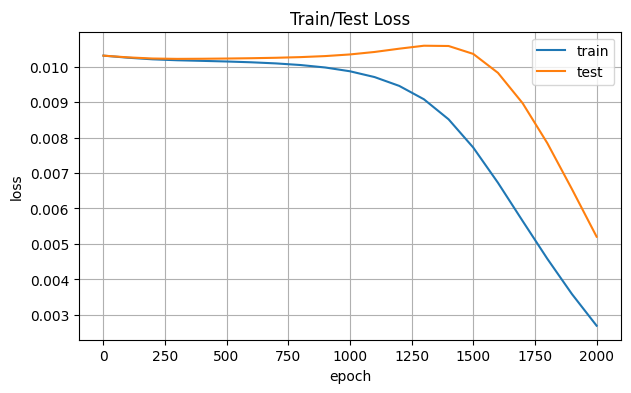

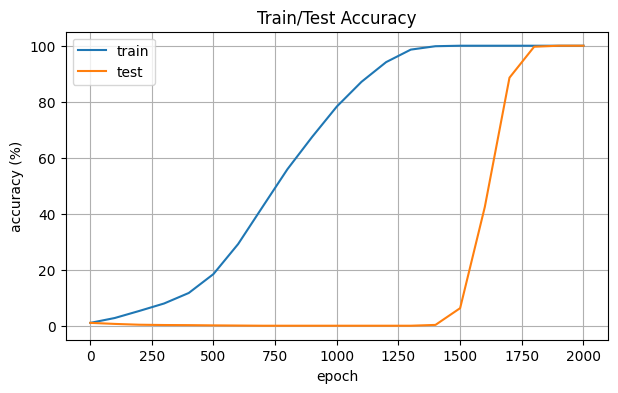

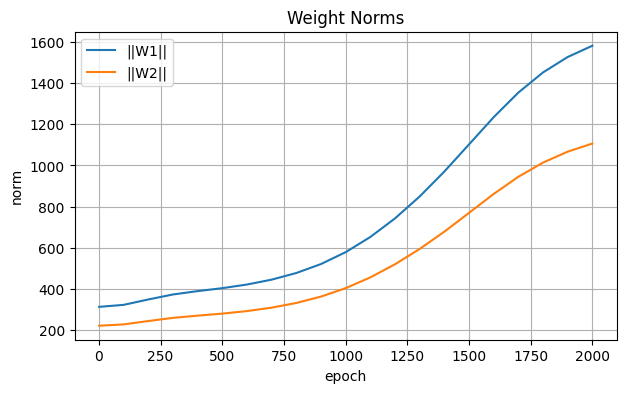

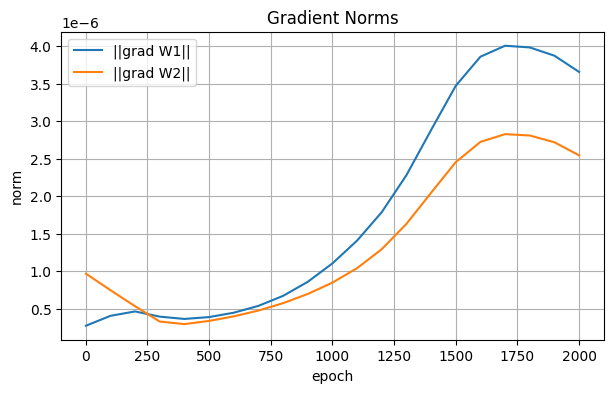

In [11]:
plot_losses(history)
plot_accuracy(history)
plot_weight_norms(history)
plot_gradient_norms(history)

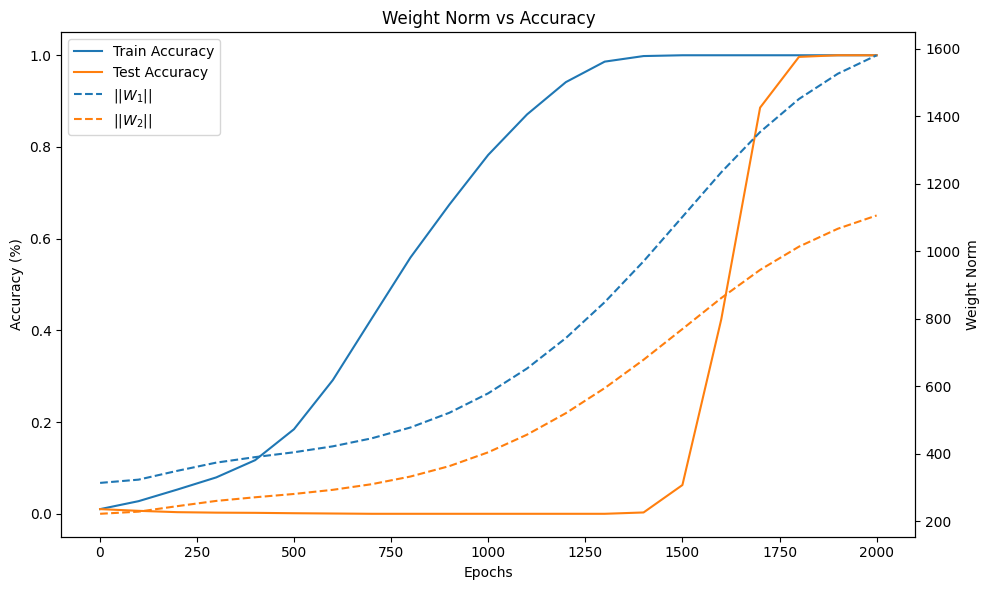

In [ ]:
import numpy as np
def plot_weight_norm_vs_accuracy(history, log_x=True):
   
    x = np.array(history["epoch"])
    x_label = "Epochs"
   

    train_acc = np.array(history["train_acc"])
    test_acc  = np.array(history["test_acc"])
    w1_norm   = np.array(history["w1_norm"])
    w2_norm   = np.array(history["w2_norm"])

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    # accuracy curves
    ax1.plot(x, train_acc, label="Train Accuracy")
    ax1.plot(x, test_acc, label="Test Accuracy")

    # norm curves
    ax2.plot(x, w1_norm, linestyle="--", label=r"$||W_1||$")
    ax2.plot(x, w2_norm, linestyle="--", label=r"$||W_2||$")

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("Accuracy (%)")
    ax2.set_ylabel("Weight Norm")

    if log_x:
        ax1.set_xscale("log")
        ax2.set_xscale("log")

    # combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

    plt.title("Weight Norm vs Accuracy")
    plt.tight_layout()
    plt.show()

plot_weight_norm_vs_accuracy(history=history)